#  Titanic Dataset — Exploratory Data Analysis

A structured walkthrough of the Titanic dataset: loading the data, inspecting
its structure, and visualizing the key factors associated with passenger
survival (class, gender, age, fare, embarkation port, and family size).

## Imports 

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

##  Load the Dataset

In [3]:
print("=" * 50)
print("Loading Titanic Dataset...")
print("=" * 50)

train = pd.read_csv("database/train.csv")
test = pd.read_csv("database/test.csv")
gender_submission = pd.read_csv("database/gender_submission.csv")

Loading Titanic Dataset...


## Dataset Observations

In [4]:
print("\n" + "=" * 50)
print("TITANIC DATASET OBSERVATIONS")
print("=" * 50)


TITANIC DATASET OBSERVATIONS


### Shape of Train / Test Sets

In [5]:
print("\nTrain Dataset Shape:", train.shape)
print("Test Dataset Shape:", test.shape)


Train Dataset Shape: (891, 12)
Test Dataset Shape: (418, 11)


### Train Data Info

In [6]:
print("\n========== TRAIN DATA INFO ==========")
print(train.info())


========== TRAIN DATA INFO ==========
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


### First 5 Rows

In [7]:
print("\n========== FIRST 5 ROWS ==========")
print(train.head())


========== FIRST 5 ROWS ==========
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0           

### Missing Values

In [8]:
print("\n========== MISSING VALUES ==========")
print(train.isnull().sum())


========== MISSING VALUES ==========
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Statistical Summary

In [9]:
print("\n========== STATISTICAL SUMMARY ==========")
print(train.describe(include="all"))


========== STATISTICAL SUMMARY ==========
        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000                      891   891   
unique          NaN         NaN         NaN                      891     2   
top             NaN         NaN         NaN  Braund, Mr. Owen Harris  male   
freq            NaN         NaN         NaN                        1   577   
mean     446.000000    0.383838    2.308642                      NaN   NaN   
std      257.353842    0.486592    0.836071                      NaN   NaN   
min        1.000000    0.000000    1.000000                      NaN   NaN   
25%      223.500000    0.000000    2.000000                      NaN   NaN   
50%      446.000000    0.000000    3.000000                      NaN   NaN   
75%      668.500000    1.000000    3.000000                      NaN   NaN   
max      891.000000    1.000000    3.000000                      NaN   NaN   

               Age  

### Overall Survival Rate

In [10]:
print("\n========== SURVIVAL RATE ==========")
survival_rate = train["Survived"].mean() * 100
print(f"Overall Survival Rate: {survival_rate:.2f}%")


========== SURVIVAL RATE ==========
Overall Survival Rate: 38.38%


## Plot Styling & Feature Engineering

In [11]:
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)

In [12]:
train = train.copy()
train["Age"] = train["Age"].fillna(train["Age"].median())
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1

##  Visualizations

### Survival Count

C:\Users\Kartavya Patel\AppData\Local\Temp\ipykernel_12504\2564988206.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


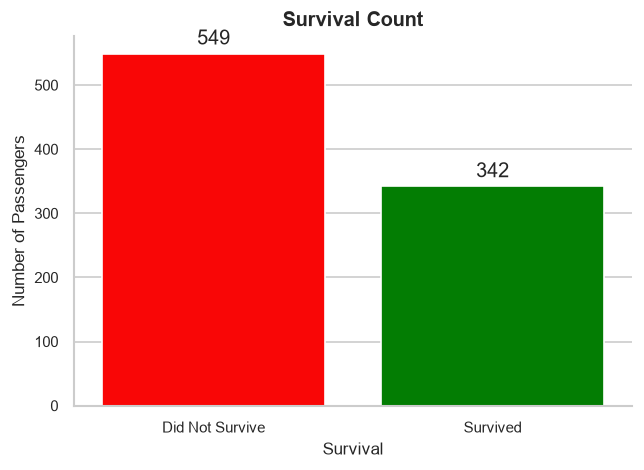

In [13]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
sns.countplot(
    data=train,
    x="Survived",
    palette=["red", "green"],
    saturation=0.95,
    ax=ax,
)
ax.set_title("Survival Count")
ax.set_xlabel("Survival")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Did Not Survive", "Survived"])
ax.set_ylabel("Number of Passengers")
ax.spines[["top", "right"]].set_visible(False)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.show()

### Survival Rate by Gender

C:\Users\Kartavya Patel\AppData\Local\Temp\ipykernel_12504\4214616154.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


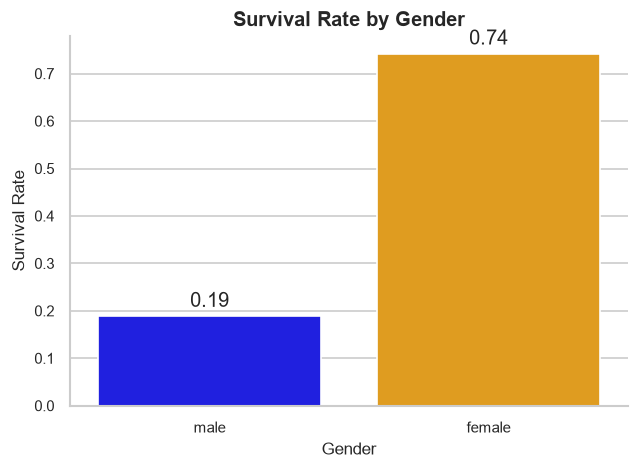

In [14]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
sns.barplot(
    data=train,
    x="Sex",
    y="Survived",
    estimator="mean",
    errorbar=None,
    palette=["blue", "orange"],
    ax=ax,
)
ax.set_title("Survival Rate by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Survival Rate")
ax.spines[["top", "right"]].set_visible(False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
plt.show()

### Survival Rate by Passenger Class

C:\Users\Kartavya Patel\AppData\Local\Temp\ipykernel_12504\3296171132.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


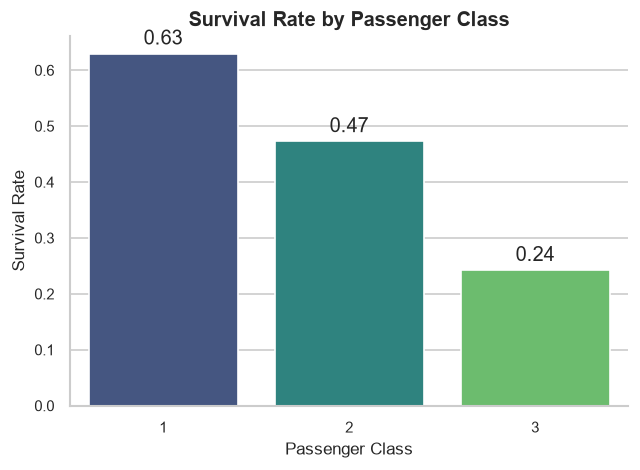

In [15]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
sns.barplot(
    data=train,
    x="Pclass",
    y="Survived",
    estimator="mean",
    errorbar=None,
    palette="viridis",
    ax=ax,
)
ax.set_title("Survival Rate by Passenger Class")
ax.set_xlabel("Passenger Class")
ax.set_ylabel("Survival Rate")
ax.spines[["top", "right"]].set_visible(False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
plt.show()

### Age Distribution by Survival

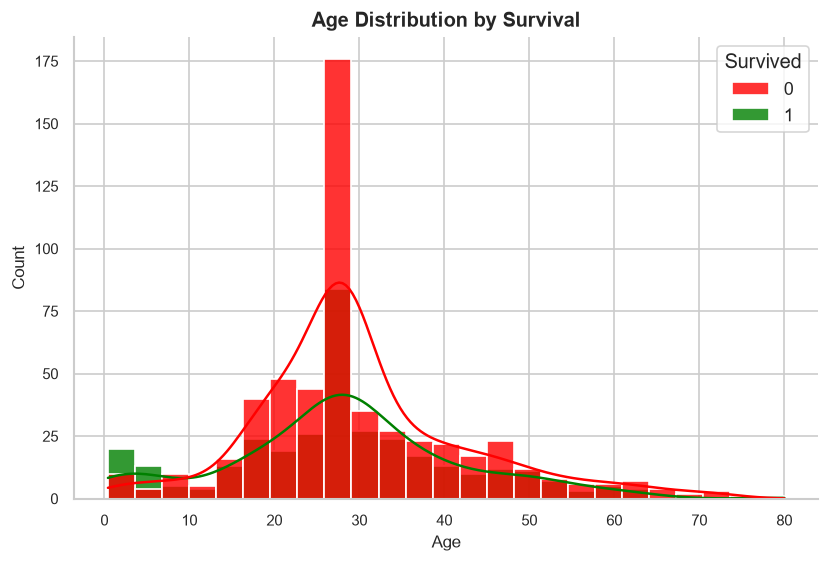

In [16]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
sns.histplot(
    data=train,
    x="Age",
    hue="Survived",
    bins=25,
    kde=True,
    palette=["red", "green"],
    alpha=0.8,
    ax=ax,
)
ax.set_title("Age Distribution by Survival")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Overall Age Distribution

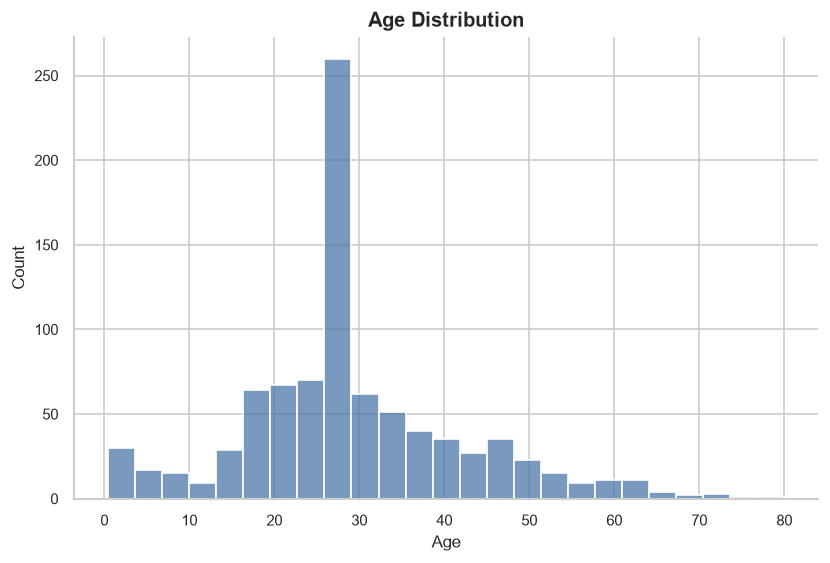

In [17]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
sns.histplot(train["Age"], bins=25, color="#4c78a8", edgecolor="white", ax=ax)
ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Fare Distribution

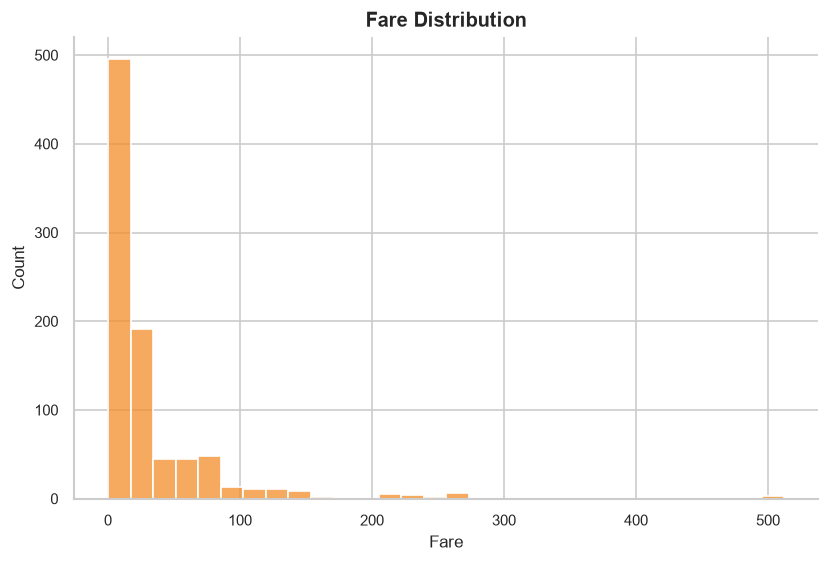

In [18]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
sns.histplot(train["Fare"], bins=30, color="#f28e2b", edgecolor="white", ax=ax)
ax.set_title("Fare Distribution")
ax.set_xlabel("Fare")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

### Survival Rate by Embarkation Port

C:\Users\Kartavya Patel\AppData\Local\Temp\ipykernel_12504\2019497407.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


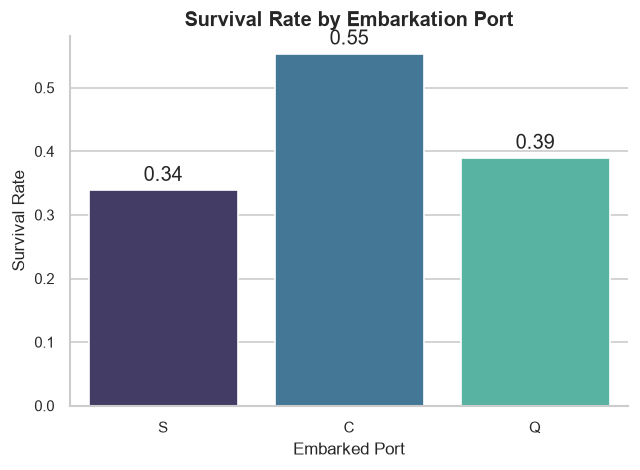

In [19]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
sns.barplot(
    data=train,
    x="Embarked",
    y="Survived",
    estimator="mean",
    errorbar=None,
    order=["S", "C", "Q"],
    palette="mako",
    ax=ax,
)
ax.set_title("Survival Rate by Embarkation Port")
ax.set_xlabel("Embarked Port")
ax.set_ylabel("Survival Rate")
ax.spines[["top", "right"]].set_visible(False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
plt.show()

### Survival Rate by Family Size

C:\Users\Kartavya Patel\AppData\Local\Temp\ipykernel_12504\2077083126.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


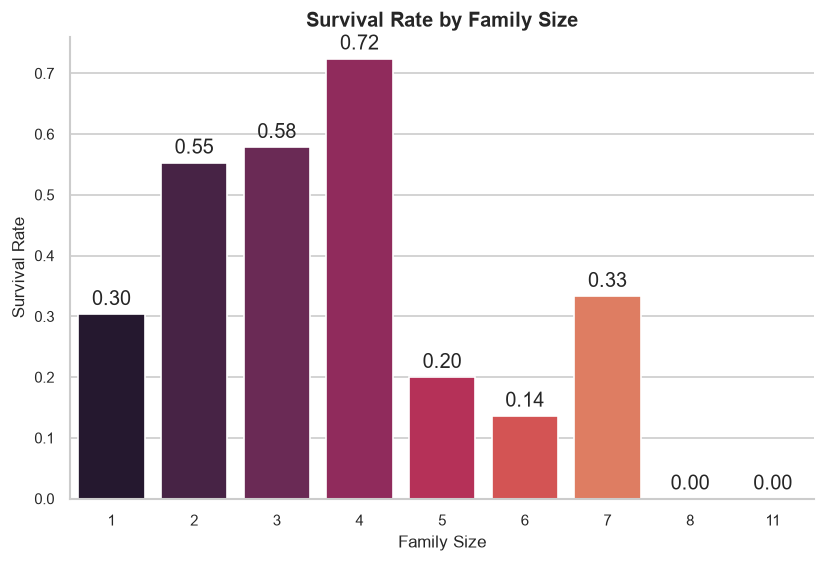

In [20]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
sns.barplot(
    data=train,
    x="FamilySize",
    y="Survived",
    estimator="mean",
    errorbar=None,
    palette="rocket",
    ax=ax,
)
ax.set_title("Survival Rate by Family Size")
ax.set_xlabel("Family Size")
ax.set_ylabel("Survival Rate")
ax.spines[["top", "right"]].set_visible(False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
plt.show()

### Correlation Heatmap

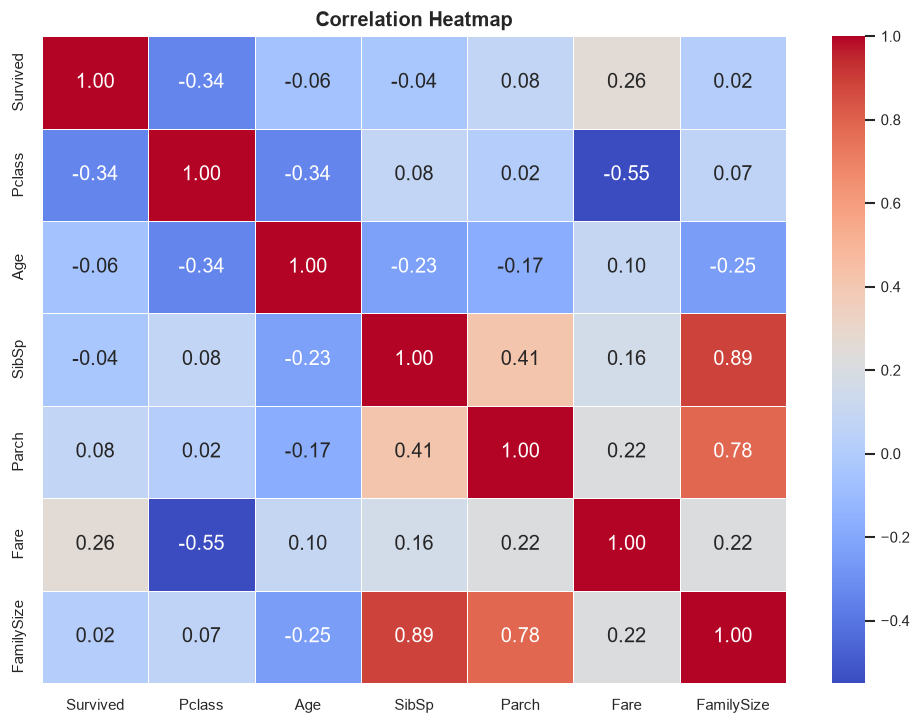

In [21]:
numeric_columns = train.select_dtypes(include=["number"]).drop(
    columns=["PassengerId"], errors="ignore"
)

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
sns.heatmap(
    numeric_columns.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=False,
    ax=ax,
)
ax.set_title("Correlation Heatmap")
plt.show()

##  Done

In [22]:
print("Analysis Completed Successfully!")

Analysis Completed Successfully!
